<img src="Logo_UNSAM.png" width="180">

### Análisis y Procesamiento de Señales

# Trabajo Práctico N°2: Modelización de un ADC

### Paulina Benito

En el siguiente informe se realiza la modelización de un ADC con el objetivo de estudiar el comportamiento de la señal, el ruido y el paso de cuantización. 

Con respecto a la señal, se simula una senoidal con energía normalizada con varianza unitaria. Como se trata de una señal sin componente continua, su valor medio será cero  y la potencia va a coincidir con la varianza. Esto se usa para ajustar la amplitud de la señal debido a que: 

$$
P_s= \frac{A^2}{2}
$$
entonces despejando se obtiene que $A= \sqrt{2}$. La señal senoidal queda definida como: 

In [277]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import kstest
import pandas as pd

def funcion_sen( vmax , dc, ph, N,  fs) : 
    nn= np.arange(0,N)
    xx = dc + vmax * np.sin(2*np.pi*(fs/N)*nn/fs + ph)

    return nn,xx

Para la simulación del ADC se toman $B$ bits en un rango de entrada de $+/-V_F$. Con la cantidad de bits se determina la cantidad de niveles de cuantización disponibles y el rango total de tensión es $2V_F$. A partir de estos parámetros, se obtiene el paso de cuantización $(q)$:
$$ 
q= \frac{2V_F}{2^B}
$$
el cual representa la distancia entre niveles del ADC. 

Por otro lado, para la generación del ruido se tienen que tener en cuentra ciertas condiciones. Tendrá carácter aditivo, es decir que la señal que ingrese al ADC será una suma entre la senoidal y un ruido analógico, generado a partir de un generador de ruido. Dicho generador será constituído para que el ruido sea aleatorio, siga una distribución normal y sus muestras sean incorreladas (que no tengan relación lineal entre sí independientemente del instante donde fueron tomadas). Por último la potencia de ruido quedará definida como: 
$$ 
P_n= k*P_q
$$
donde $k$ es un factor de escala y $P_q$ la potencia de ruido de cuantización, la cual se calcula de la siguiente manera: 
$$
P_q=\frac{q^2}{12}
$$

In [278]:
VF=2
B=4
qq = 2*VF/(2**B)

def gen_noise(k, qq, ur=0, nn=N):
    Pq = qq**2 / 12
    Pn = k * Pq
    desv = np.sqrt(Pn)
    ruido = np.random.normal(ur, desv, nn)

    return ruido, Pn

A continuación se iniciaran la series de simulaciones tomando los siguientes valores $VF=2$, $N=1000$, $f_s=1000Hz$, variando la cantidad de bits y el $k$.

#### 1. Primera simulación: análisis con B=4 y k=1

Para la primera simulación se consideran $B=4$ bits y $k=1$. Se analizará la evolución de la señal desde la senoidal ideal hasta la entrada y salida del ADC, observando los efectos introducidos por el ruido analógico y por la cuantización.

##### 1.1 Análisis temporal de la entrada al ADC

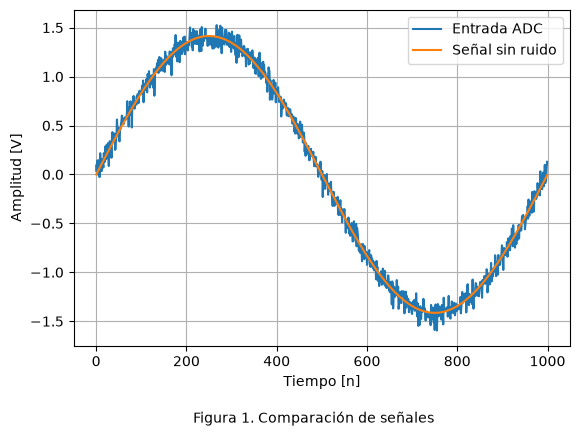

In [279]:
vmax= np.sqrt(2)
N=1000
ph=0
dc=0
fs=1000
#funcion ideal 
nn,xx= funcion_sen(vmax, dc, ph, N, fs)
#función entrada al ADC
VF=2
B=4
k=1
ruido, Pn= gen_noise(k, qq)
noisy_xx= xx + ruido

plt.figure()
plt.plot(nn, noisy_xx,label="Entrada ADC")
plt.plot(nn, xx, label="Señal sin ruido")

plt.xlabel("Tiempo [n]")
plt.ylabel("Amplitud [V]")
plt.subplots_adjust(bottom=0.18)

plt.figtext(0.5, 0.02,
            "Figura 1. Comparación de señales",
            ha="center")
plt.legend()
plt.grid()
plt.show()

En la Figura 1 se observa la señal senoidal ideal y la señal a la entrada del ADC. La señal de entrada incluye el ruido analógico aditivo, por lo que presenta fluctuaciones alrededor de la senoide original. Estas diferencias permiten visualizar el efecto de la contaminación de la señal antes de la etapa de cuantización.


##### 1.2 Análisis espectral de la entrada al ADC



En este paso, se estudia la densidad espectral de potencia mediante el gráfico de módulo de la FFT y su fase. Dicho gráfico es útil para saber como se distribuye la energía/potencia en la señal y ayuda a distinguirla del ruido. 

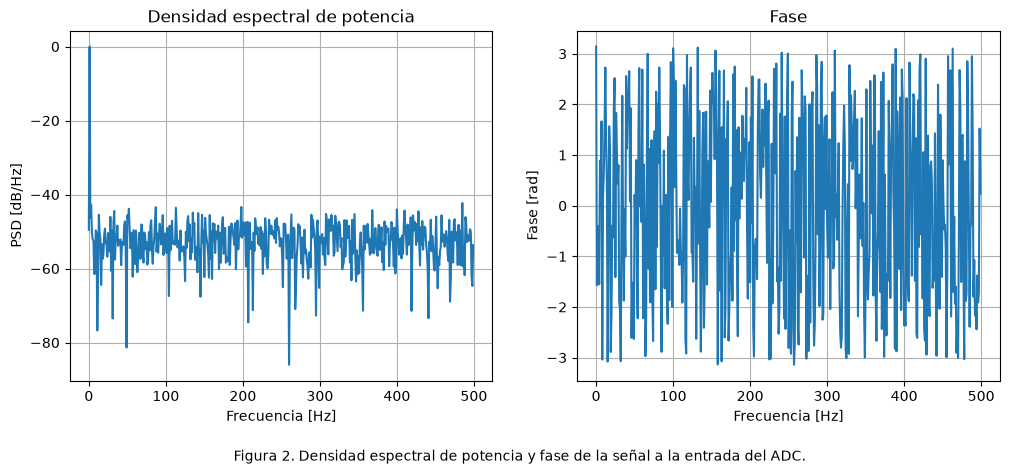

In [280]:
frec=np.arange(N//2) * fs/N
nXX = 1/N*np.fft.fft(noisy_xx)
A = nXX[:N//2]
PSD= 10*np.log10(2*(np.abs(nXX[:N//2])**2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Gráfico de la izquierda
ax1.plot(frec, PSD)
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("PSD [dB/Hz]")
ax1.set_title("Densidad espectral de potencia")
ax1.grid(True)

# Gráfico de la derecha
ax2.plot(frec, np.angle(A))
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Fase [rad]")
ax2.set_title("Fase")
ax2.grid(True)

plt.subplots_adjust(bottom=0.18)

plt.figtext(0.5, 0.02,
            "Figura 2. Densidad espectral de potencia y fase de la señal a la entrada del ADC.",
            ha="center")
plt.show()

En la Figura 2 se presenta el análisis en frecuencia de la señal a la entrada del ADC. En la densidad espectral de potencia se observa un pico dominante correspondiente a la frecuencia de la señal senoidal, mientras que el ruido analógico se distribuye sobre un amplio rango de frecuencias, formando un piso espectral aproximadamente uniforme. Esto permite diferenciar la componente útil de la señal del contenido asociado al ruido.

En el gráfico de fase se representa el ángulo de la FFT para cada componente frecuencial. Debido a la presencia de ruido aleatorio, la fase presenta valores distribuidos entre aproximadamente $-\pi$ y $\pi$ en gran parte del espectro. La fase resulta especialmente significativa en las frecuencias donde existe una componente espectral con amplitud apreciable.

##### 1.3 Cuantización
Como ya se generó la señal de entrada al ADC $(S_E)$, se realiza el proceso de cuantización. Debido a que el conversor tiene una cantidad finita de bits, no puede representar cualquier valor de amplitud, sino únicamente un conjunto discreto de niveles separados por el paso de cuantización $q$. Por lo tanto, cada muestra de la señal de entrada es aproximada al nivel disponible más cercano. Para lograr esto, se aplica un redondeo a la señal de entrada, obteniendo la señal cuantizada: 
$$ S_q= q*round(\frac{S_E}{q})
$$

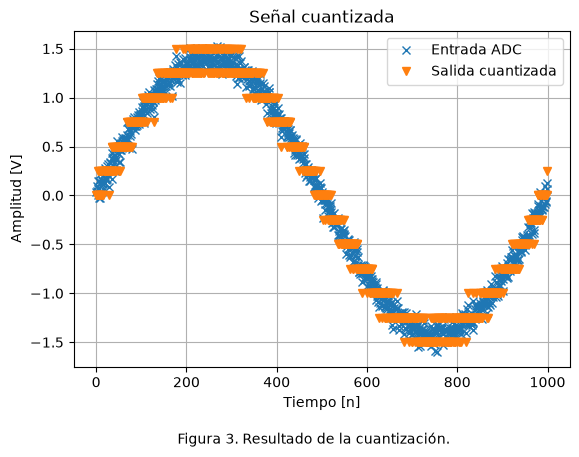

In [281]:
#Cuantización
xx_q= np.round(noisy_xx/qq)*qq
plt.figure()
plt.plot(nn, noisy_xx, "x", label="Entrada ADC")
plt.plot(nn, xx_q, "v", label="Salida cuantizada")
plt.xlabel("Tiempo [n]")
plt.ylabel("Amplitud [V]")
plt.title("Señal cuantizada")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 3. Resultado de la cuantización.",
            ha="center")
plt.legend()
plt.grid()
plt.show()

En la Figura 3 se observa claramente el efecto de la cuantización. La señal de entrada es aproximada a un conjunto discreto de niveles disponibles en el ADC. Estos niveles se encuentran separados por el paso de cuantización:
$q=\frac{2V_F}{2^B}=\frac{2*2}{2^4}= 0.25$

Por ende, cada muestra es redondeada al nivel de cuantización más cercano, generándose así una diferencia entre el valor original de entrada y el valor finalmente representado por el ADC. Para visualizar con mayor detalle este efecto de redondeo, en la Figura 4 se hizo un zoom.

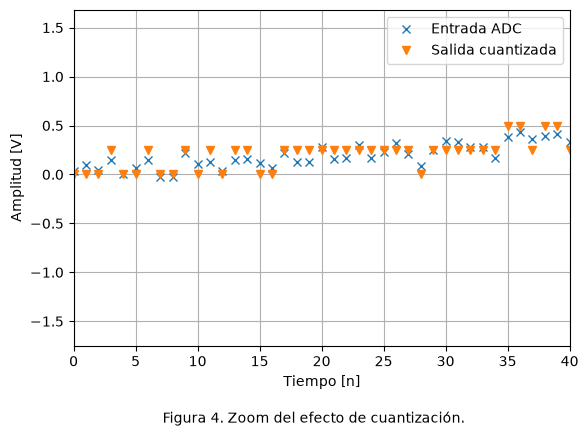

In [282]:
plt.figure()
plt.plot(nn, noisy_xx, "x", label="Entrada ADC")
plt.plot(nn, xx_q, "v", label="Salida cuantizada")
plt.xlabel("Tiempo [n]")
plt.ylabel("Amplitud [V]")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 4. Zoom del efecto de cuantización.",
            ha="center")
plt.legend()
plt.grid()
plt.xlim(0, 40)
plt.show()

Al realizar una cuantización se introduce el error de cuantización, el cual es la diferencia entre la señal cuantizada y la de entrada al ADC.

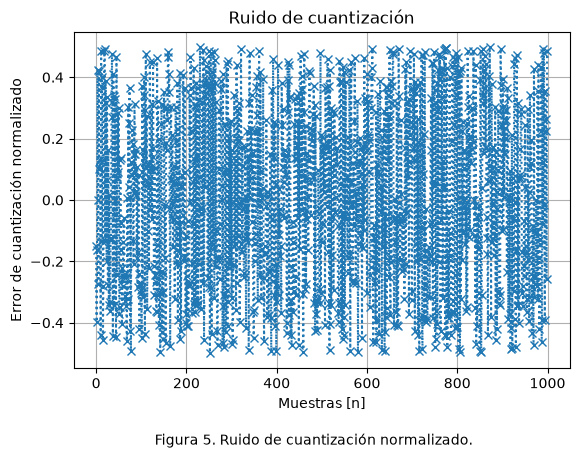

In [283]:
ruido_q= xx_q - noisy_xx
plt.figure()
plt.plot(nn, ruido_q/qq,':x')
plt.xlabel("Muestras [n]")
plt.ylabel("Error de cuantización normalizado")
plt.title("Ruido de cuantización")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 5. Ruido de cuantización normalizado.",
            ha="center")

plt.grid()


En la Figura 5 se presenta el error de cuantización normalizado, definido como $\frac{e_q[n]}{q}$, donde $e_q[n]$ es la diferencia entre la señal cuantizada y la señal de entrada al cuantizador. Se observa que sus valores quedan acotados aproximadamente entre $-0.5$ y $0.5$, lo cual resulta lo esperable por el redondeo. Además, el error varía alrededor de cero, sin mostrar una tendencia determinística evidente. Por ende, para saber si el ruido sigue efectivamente una distribución uniforme y es incorrelado, se deberán evaluar una serie de cosas. 

Primero, para saber si es de distribución uniforme se estudia su histograma.

varianza experimental= 0.0882195596427057


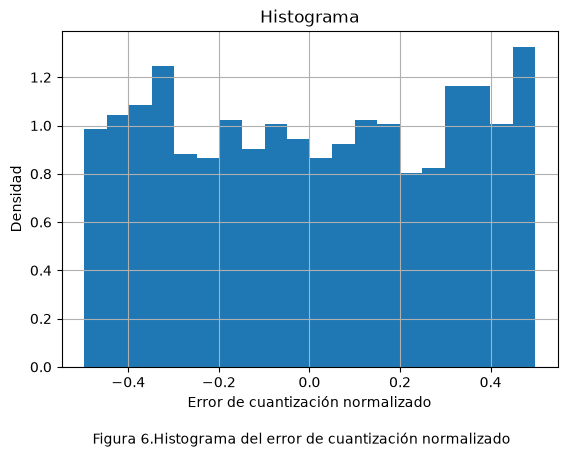

In [284]:
plt.figure()
plt.hist(ruido_q/qq, bins=20, density=True)
plt.xlabel("Error de cuantización normalizado")
plt.ylabel("Densidad")
plt.title("Histograma")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 6.Histograma del error de cuantización normalizado",
            ha="center")

plt.grid(True)
plt.show

#varianza
print("varianza experimental=", np.var(ruido_q/qq))

En la Figura 6 se observa el histograma del error de cuantización normalizado $\frac{e_q[n]}{q}$. Los valores se encuentran comprendidos aproximadamente entre  $+/-0.5$, intervalo esperado para un cuantizador por redondeo. Además, las barras presentan alturas relativamente similares a lo largo de dicho intervalo, lo que resulta compatible visualmente con una distribución uniforme.

Por otro lado, se calcula la varianza experimental, obteniendo aproximadamente $\sigma^2=0.085955$. Este valor es cercano a la varianza teórica:
 $$ \sigma^2= \frac{(0.5-(-0.5))^2}{12}= 0.0833333$$


In [285]:
a=-qq/2
b=qq/2

resultado= kstest(ruido_q, "uniform", args=(a, b-a))

alpha= 0.5

if resultado.pvalue < alpha: 
    print("La señal no es compatible con una distribución uniforme.")
else: 
    print("No hay evidencia suficiente para confirmar que la señal no sigue una distribución uniforme.")

La señal no es compatible con una distribución uniforme.


Finalmente, se realiza un test de hipótesis para comparar las muestras del error de cuantización con una distribución uniforme teórica en el intervalo $[-q/2,q/2]$. Al no obtener evidencia suficiente para rechazar la hipótesis nula, el resultado del test es consistente con el modelo uniforme observado previamente en el histograma y en el análisis de la varianza.

Por lo tanto, a partir del histograma, la comparación de varianzas y el test de hipótesis, puede considerarse que el error de cuantización presenta un comportamiento aproximadamente uniforme. Sin embargo, estos análisis no permiten determinar si las muestras están correlacionadas entre sí, ya que describen principalmente su distribución estadística. Para estudiar esta propiedad se analiza posteriormente la autocorrelación del error.

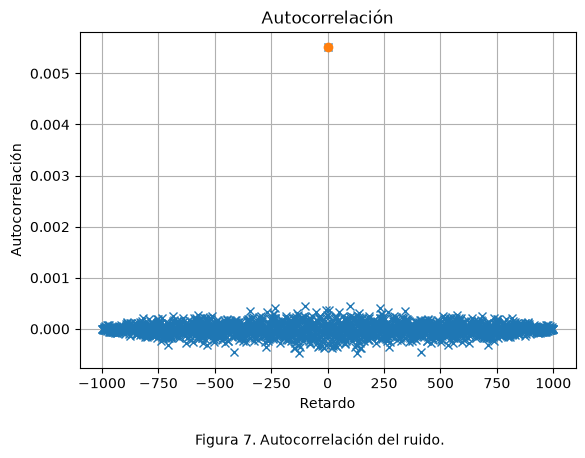

In [286]:

ruido_centrado = ruido_q - np.mean(ruido_q)
R = (np.correlate(ruido_centrado, ruido_centrado, mode="full") / len(ruido_q))
centro=len(R)//2
retardo_0= R[centro]

varianza = np.var(ruido_q)
retardo_neg = np.arange(-N+1, N)

plt.figure()
plt.plot(retardo_neg, R, "x")
plt.plot(0, R[centro], "o")

plt.xlabel("Retardo")
plt.ylabel("Autocorrelación")
plt.title("Autocorrelación")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 7. Autocorrelación del ruido.",
            ha="center")
plt.grid()
plt.show()

Para que un proceso se considere incorrelado en este caso, para retardos distintos de cero los valores de la autocorrelación deben oscilar alrededor de cero, mientras que para retardo cero aparece un valor no nulo que coincide aproximadamente con la varianza. Como se observa en la Figura 7, la autocorrelación presenta este comportamiento y puede decirse que tiene una forma similar a una delta. Por ende, se puede considerar que el ruido de cuantización presenta un comportamiento aproximadamente incorrelado.

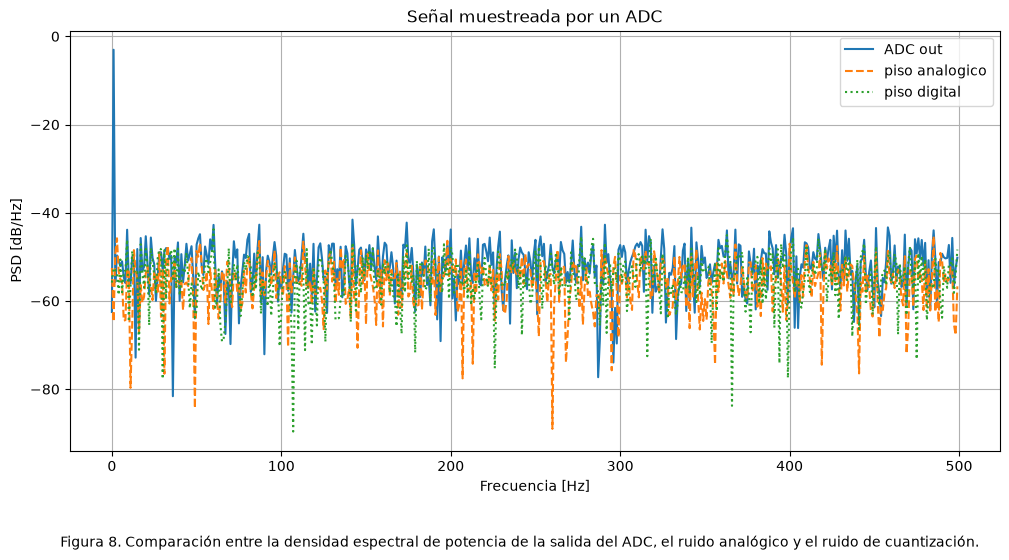

In [287]:
def espectro_potencia(x):
    X = np.fft.fft(x) / N
    PSD =  (N/fs) * np.abs(X[:N//2])**2  #aca me quedo solo con el rango de 0 a nyquist
    P_db = 10 * np.log10(PSD + 1e-20) #el valor chico queda para que si P=0 no me tire error
    return P_db

P_s = espectro_potencia(xx)
P_in = espectro_potencia(noisy_xx)
P_q = espectro_potencia(xx_q)

P_ruido = espectro_potencia(ruido)
P_ruido_q = espectro_potencia(ruido_q)

#valores medios
piso_ruido = 10*np.log10(np.mean(10**(P_ruido/10)))
piso_ruido_q = 10*np.log10(np.mean(10**(P_ruido_q/10)))


plt.figure(figsize=(12,6))
plt.plot(frec, P_q,
         label="ADC out")
plt.plot(frec, P_ruido, "--",
         label= "piso analogico")
plt.plot(frec, P_ruido_q, ":",
         label="piso digital")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.title("Señal muestreada por un ADC")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 8. Comparación entre la densidad espectral de potencia de la salida del ADC, el ruido analógico y el ruido de cuantización.",
            ha="center")
plt.grid()
plt.legend()
plt.show()

En la Figura 8 se comparan las densidades espectrales de potencia de la salida del ADC, del ruido analógico y del error de cuantización. Como para esta simulación $k_n=1$, la potencia del ruido analógico fue definida igual a la potencia teórica del ruido de cuantización, por lo que ambos pisos espectrales presentan niveles similares. Las diferencias puntuales entre ambas curvas se deben al carácter aleatorio de las secuencias y a que se trabaja con una cantidad finita de muestras.

En la salida del ADC se observa además un pico dominante en $f_0=1Hz$, correspondiente a la señal senoidal útil. Fuera de dicha frecuencia, el nivel de la curva de salida se encuentra ligeramente por encima de los pisos individuales de ruido. Esto se debe a que en la salida están presentes simultáneamente el ruido analógico y el error de cuantización. Si ambas contribuciones se consideran incorreladas, sus potencias pueden sumarse y, al tener aproximadamente la misma potencia, la potencia total del ruido es aproximadamente $3dB$ superior a cada contribución por separado.

Para concluir, en estaprimera simulación se trabajó con un ADC de $B=4$ bits, un rango de entrada de $+/- 2V$ y un factor $k=1$. A partir de la cantidad de bits y del rango del ADC se obtiene un paso de cuantización de $q=0.25V$, es decir que los niveles disponibles del conversor se encuentran separados entre sí por $0.25V$. Este paso permite calcular la potencia teórica del ruido de cuantización mediante $P_q=\frac{q^2}{12}$, obteniéndose aproximadamente $P_q=0.00521V^2$. Como para este caso $k=1$ y la consigna establece que $P_n=kP_q$, la potencia del ruido analógico agregado resulta igual a la potencia del ruido de cuantización. Esto no quiere decir que ambos ruidos sean iguales, ya que uno se agrega antes de ingresar al ADC y el otro aparece como consecuencia de la cuantización, sino que en esta simulación poseen la misma potencia (ver Figura 8).

A partir de estas potencias también puede calcularse la relación señal-ruido o SNR, que indica cuánto mayor es la potencia de la señal útil respecto de la potencia del ruido. Como la senoidal utilizada fue normalizada para tener potencia $P_s=1$, la SNR respecto del ruido analógico se calcula como $SNR=10\log_{10}\frac{P_s}{P_n}$, dando aproximadamente $SNR=22.83dB$. Esto indica que la potencia de la señal es considerablemente mayor que la del ruido. Como en este caso $P_n=P_q$ , la SNR respecto del ruido de cuantización resulta igual. Finalmente, si se consideran en conjunto ambas contribuciones de ruido y se supone que son incorreladas, sus potencias pueden sumarse, obteniéndose una SNR total de aproximadamente $19.82 dB$. Por lo tanto, al considerar simultáneamente el ruido analógico y el de cuantización, la relación señal-ruido empeora respecto de analizar cada uno por separado.

#### 2. Segunda simulación: variantes de B y k

Para la siguiente simulación se repetirá el punto 1 pero con diferentes valores de bits y de k con el objetivo de estudiar el comportamiento del ADC al modificar la resolución y la importancia del ruido de cuantización respecto al analógico. Para ello, se estudiará los gráficos de señal de entrada vs cuantizada, la densidad espectral de potencia y se calculará la relación señal-ruido (SNR) en cada caso. 

In [288]:
def calcular_snr(B, k):
    VF = 2
    Psen = 1
    q = 2*VF/(2**B)
    Pq = q**2 / 12
    Pn = k * Pq
    
    SNR_q = 10*np.log10(Psen/Pq)
    SNR_n = 10*np.log10(Psen/Pn)
    SNR_total = 10*np.log10(Psen/(Pq + Pn))
    
    print("SNR cuantización =", SNR_q, "dB")
    print("SNR analógica =", SNR_n, "dB")
    print("SNR total =", SNR_total, "dB")

##### 2.1 Con k=1 y variando B
##### 2.1.1 B=8

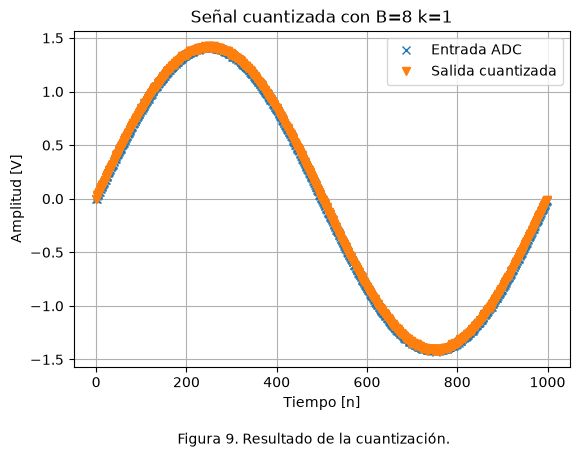

In [289]:
B = 8
k= 1
VF = 2

qq = 2*VF/(2**B)
ruido, Pn = gen_noise(k, qq)
noisy_xx= xx + ruido

xx_q = np.round(noisy_xx/qq)*qq
ruido_q = xx_q - noisy_xx

plt.plot(nn, noisy_xx, "x", label="Entrada ADC")
plt.plot(nn, xx_q, "v", label="Salida cuantizada")
plt.xlabel("Tiempo [n]")
plt.ylabel("Amplitud [V]")
plt.title("Señal cuantizada con B=8 k=1")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 9. Resultado de la cuantización.",
            ha="center")
plt.legend()
plt.grid()
plt.show()

Al tener una resolución de 8 bits, habrán 256 niveles disponibles. Dichos niveles estarán separados por $q=\frac{2*2}{2^8}= 0.015625 V$ . Por eso, en la figura 9 no se perciben bien la diferencia entre niveles debido a que la separación entre niveles es muy pequeña . Para ver el efecto de la cuantización mejor, en la figura 10 se hace un zoom. 

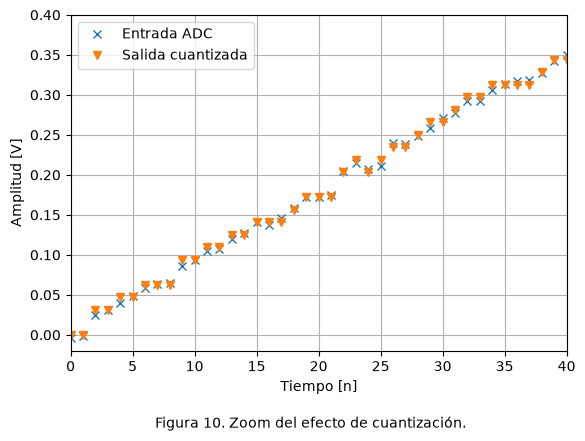

In [290]:
plt.figure()
plt.plot(nn, noisy_xx, "x", label="Entrada ADC")
plt.plot(nn, xx_q, "v", label="Salida cuantizada")
plt.xlabel("Tiempo [n]")
plt.ylabel("Amplitud [V]")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 10. Zoom del efecto de cuantización.",
            ha="center")
plt.legend()
plt.grid()
plt.xlim(0, 40)
plt.ylim(-0.02, 0.4)
plt.show()

In [291]:
calcular_snr(8,1)

SNR cuantización = 46.915411940153994 dB
SNR analógica = 46.915411940153994 dB
SNR total = 43.90511198351418 dB


Para $B=8$ y $k=1$, se obtiene una SNR de cuantización y una SNR analógica de aproximadamente $46.92 dB$. Como ambas potencias de ruido son iguales, ambas SNR coinciden. Al considerar simultáneamente las dos contribuciones, la SNR total disminuye a aproximadamente $43.91 dB$.

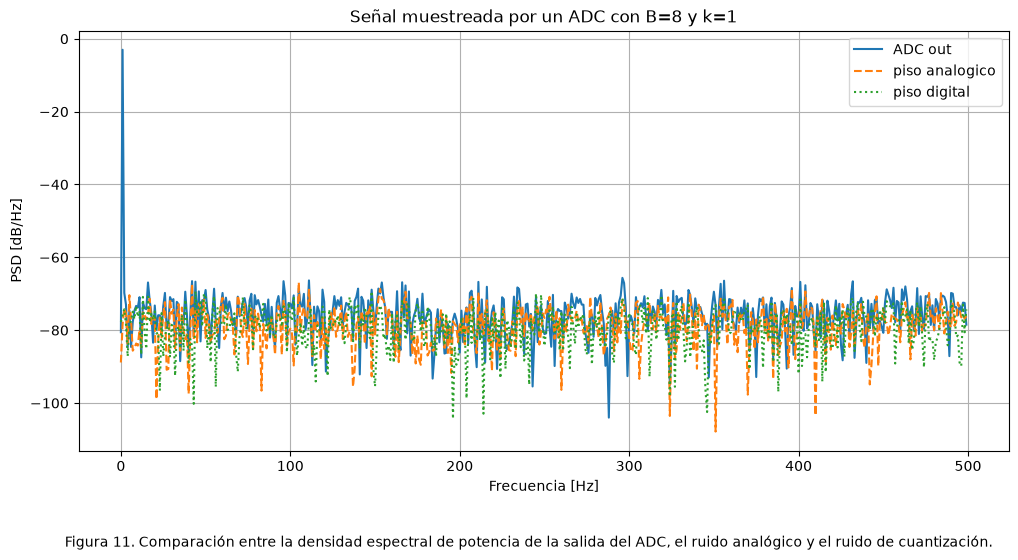

In [292]:
P_salida= espectro_potencia(xx_q)
P_ruido = espectro_potencia(ruido)
P_ruido_q = espectro_potencia(ruido_q)

#valores medios
piso_ruido = 10*np.log10(np.mean(10**(P_ruido/10)))
piso_ruido_q = 10*np.log10(np.mean(10**(P_ruido_q/10)))


plt.figure(figsize=(12,6))
plt.plot(frec, P_salida,
         label="ADC out")
plt.plot(frec, P_ruido, "--",
         label= "piso analogico")
plt.plot(frec, P_ruido_q, ":",
         label="piso digital")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.title("Señal muestreada por un ADC con B=8 y k=1")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 11. Comparación entre la densidad espectral de potencia de la salida del ADC, el ruido analógico y el ruido de cuantización.",
            ha="center")
plt.grid()
plt.legend()
plt.show()

En este caso, como no se cambió el k, la relación entre ambos pisos de ruidos se manteiene igual. Pero, a diferencia de la Figura 8, en la Figura 11 se observa que bajo a aporximadamente -80db/Hz. Esto se debe al aumento de la cantidad de bits del ADC, ya que al pasar de $B=4$ a $B=8$ disminuye el paso de cuantización q, y por lo tanto también disminuye la potencia del ruido de cuantización $P_q=\frac{q^2}{12}$. Como en esta simulación $k_n=1$, la potencia del ruido analógico también disminuye en la misma proporción, por lo que ambos pisos espectrales bajan manteniendo una relación similar entre sí. En consecuencia, al aumentar la resolución del ADC se reduce el nivel global de ruido y mejora la relación señal-ruido respecto del caso anterior.

##### 2.1.2 B=16

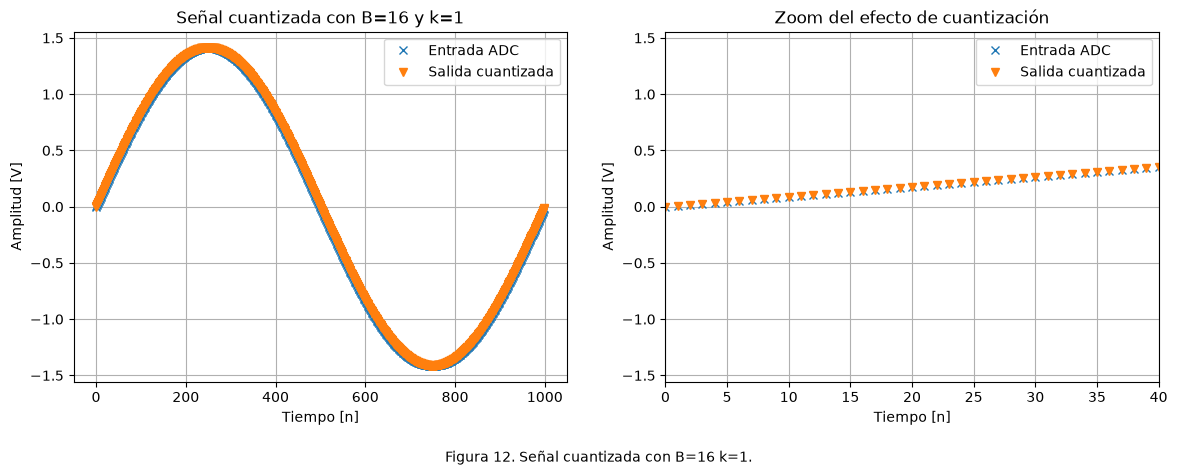

In [293]:
B = 16
k= 1
VF = 2

qq = 2*VF/(2**B)
ruido, Pn = gen_noise(k, qq)
noisy_xx= xx + ruido

xx_q = np.round(noisy_xx/qq)*qq
ruido_q = xx_q - noisy_xx

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax1.plot(nn, xx_q, "v", label="Salida cuantizada")

ax1.set_xlabel("Tiempo [n]")
ax1.set_ylabel("Amplitud [V]")
ax1.set_title("Señal cuantizada con B=16 y k=1")
ax1.legend()
ax1.grid(True)

ax2.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax2.plot(nn, xx_q, "v", label="Salida cuantizada")

ax2.set_xlim(0, 40)

ax2.set_xlabel("Tiempo [n]")
ax2.set_ylabel("Amplitud [V]")
ax2.set_title("Zoom del efecto de cuantización")
ax2.legend()
ax2.grid(True)

plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 12. Señal cuantizada con B=16 k=1.",
            ha="center")

plt.show()

En este caso, al cuantizar con 16 bits  se tendrán 65536 niveles disponibles. Dichos niveles estarán separados por $ q=\frac{4}{2^16}= 0.000061035$.Como este paso de cuantización es muy pequeño y , además hay muchos niveles, el efecto de la cuantización no se percibe fácilmente y hasta diría que ambas señales se superponen. Por lo tanto, al aumentar la cantidad de bits disminuye el paso de cuantización, reduciéndose el error asociado y permitiendo representar con mayor precisión la amplitud de la señal de entrada.

In [294]:
calcular_snr(16,1)

SNR cuantización = 95.08021124639099 dB
SNR analógica = 95.08021124639099 dB
SNR total = 92.06991128975118 dB


Para $B=16$ y $k=1$, la SNR asociada al ruido de cuantización y al ruido analógico resulta aproximadamente $95.08 dB$. Como $k=1$, ambas potencias de ruido son iguales y, por lo tanto, ambas SNR coinciden. Al considerar conjuntamente ambas contribuciones, la SNR total disminuye a aproximadamente $92.07 dB$.

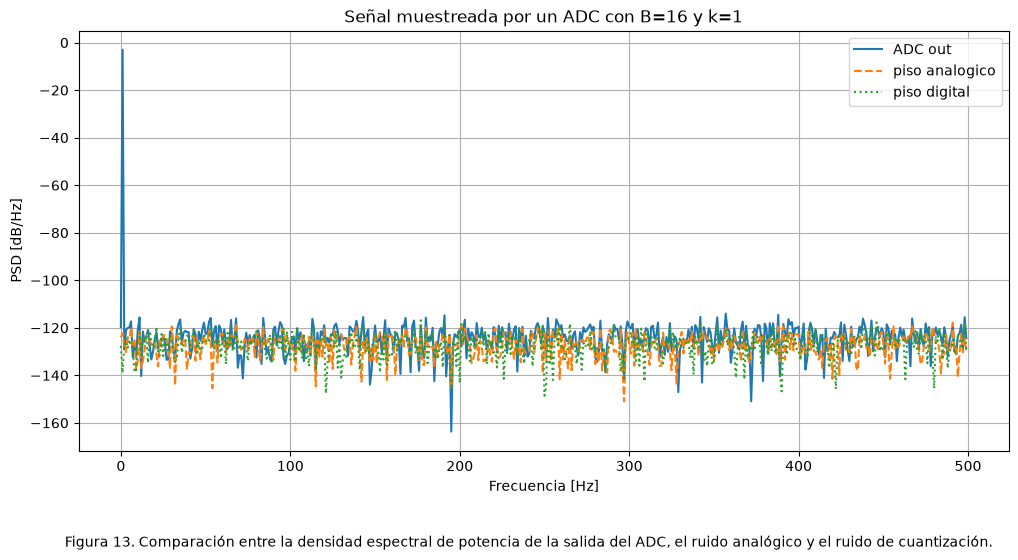

In [295]:
P_salida= espectro_potencia(xx_q)
P_ruido = espectro_potencia(ruido)
P_ruido_q = espectro_potencia(ruido_q)

#valores medios
piso_ruido = 10*np.log10(np.mean(10**(P_ruido/10)))
piso_ruido_q = 10*np.log10(np.mean(10**(P_ruido_q/10)))


plt.figure(figsize=(12,6))
plt.plot(frec, P_salida,
         label="ADC out")
plt.plot(frec, P_ruido, "--",
         label= "piso analogico")
plt.plot(frec, P_ruido_q, ":",
         label="piso digital")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.title("Señal muestreada por un ADC con B=16 y k=1")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 13. Comparación entre la densidad espectral de potencia de la salida del ADC, el ruido analógico y el ruido de cuantización.",
            ha="center")
plt.grid()
plt.legend()
plt.show()

En la Figura 13 se observa nuevamente que, al mantenerse $k=1$, los pisos correspondientes al ruido analógico y al ruido de cuantización presentan niveles similares. Sin embargo, al aumentar la resolución del ADC hasta $B=16$, ambos pisos espectrales descienden considerablemente respecto del caso de $B=8$. Esto se debe a que el aumento en la cantidad de bits disminuye el paso de cuantización, reduciendo tanto la potencia del ruido de cuantización como, debido a la relación $P_n=kP_q$, la potencia del ruido analógico utilizado en esta simulación. En consecuencia, la SNR aumenta y la señal digitalizada presenta una mayor calidad respecto de los casos de menor resolución.

##### 2.2 Con k=0.10, variando B

##### 2.2.1 B=4 

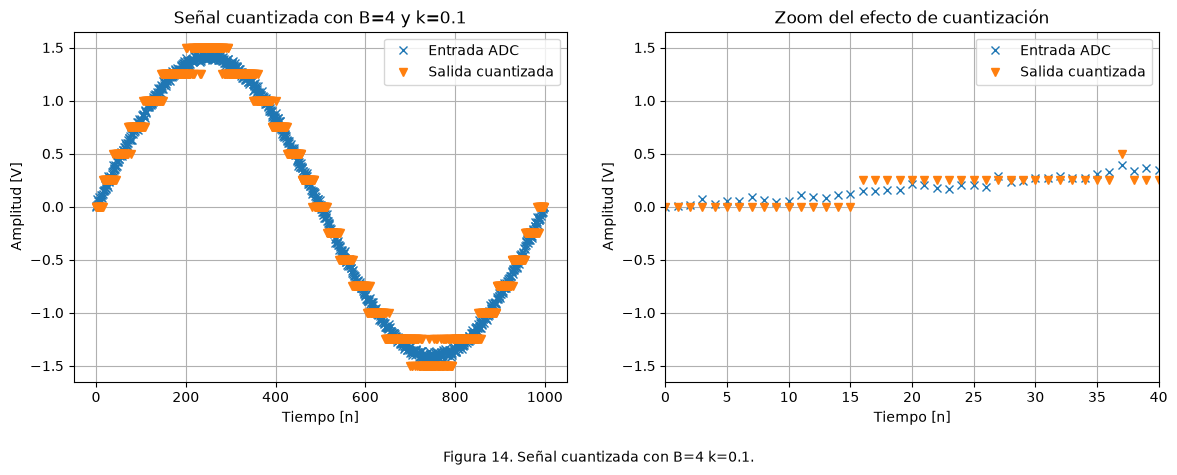

In [296]:
B = 4
k= 0.1
VF = 2

qq = 2*VF/(2**B)
ruido, Pn = gen_noise(k, qq)
noisy_xx= xx + ruido

xx_q = np.round(noisy_xx/qq)*qq
ruido_q = xx_q - noisy_xx

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax1.plot(nn, xx_q, "v", label="Salida cuantizada")

ax1.set_xlabel("Tiempo [n]")
ax1.set_ylabel("Amplitud [V]")
ax1.set_title("Señal cuantizada con B=4 y k=0.1")
ax1.legend()
ax1.grid(True)

ax2.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax2.plot(nn, xx_q, "v", label="Salida cuantizada")

ax2.set_xlim(0, 40)

ax2.set_xlabel("Tiempo [n]")
ax2.set_ylabel("Amplitud [V]")
ax2.set_title("Zoom del efecto de cuantización")
ax2.legend()
ax2.grid(True)

plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 14. Señal cuantizada con B=4 k=0.1.",
            ha="center")

plt.show()

En este caso, al usar 4 bits se tienen 16 niveles disponibles, separados por $ q=\frac{4}{16}= 0,25$. Como se observa en el zoom en la Figura 14, en comparación con los casos de 8 y 16 bits, el efecto de la cuantización vuelve a ser claramente visible debido al mayor valor de q.

In [316]:
calcular_snr(4,0.1)

SNR cuantización = 22.833012287035498 dB
SNR analógica = 32.833012287035494 dB
SNR total = 22.419085435453248 dB


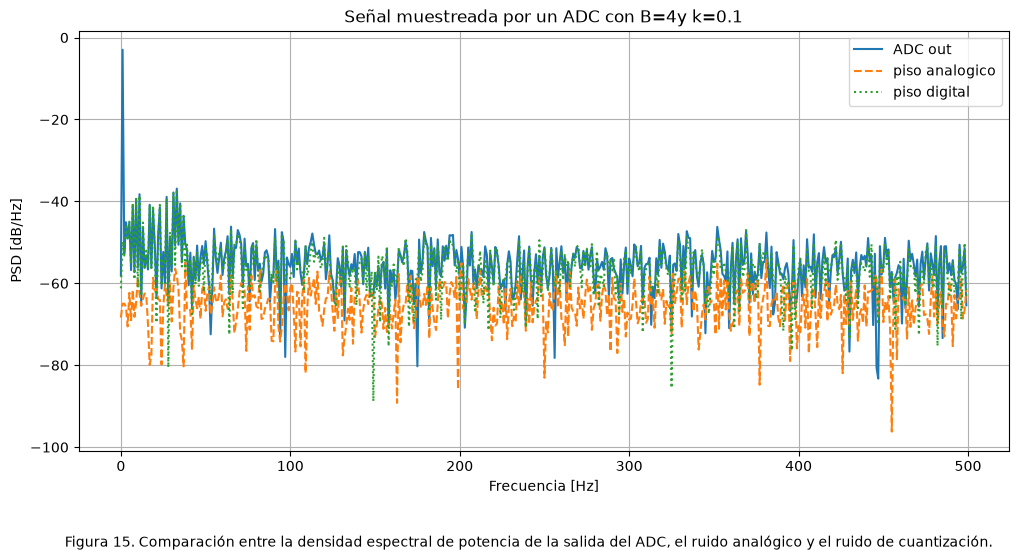

In [298]:
P_salida= espectro_potencia(xx_q)
P_ruido = espectro_potencia(ruido)
P_ruido_q = espectro_potencia(ruido_q)

#valores medios
piso_ruido = 10*np.log10(np.mean(10**(P_ruido/10)))
piso_ruido_q = 10*np.log10(np.mean(10**(P_ruido_q/10)))


plt.figure(figsize=(12,6))
plt.plot(frec, P_salida,
         label="ADC out")
plt.plot(frec, P_ruido, "--",
         label= "piso analogico")
plt.plot(frec, P_ruido_q, ":",
         label="piso digital")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.title("Señal muestreada por un ADC con B=4y k=0.1")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 15. Comparación entre la densidad espectral de potencia de la salida del ADC, el ruido analógico y el ruido de cuantización.",
            ha="center")
plt.grid()
plt.legend()
plt.show()

En este caso se mantiene $B=4$ , por lo que el paso de cuantización y la potencia del ruido de cuantización no cambian respecto de la primera simulación. Sin embargo, al utilizar $k=0.1$, la potencia del ruido analógico resulta diez veces menor que la potencia del ruido de cuantización, observándose en la densidad espectral una separación aproximada de $10 dB$ entre ambos pisos. Como consecuencia, la SNR respecto del ruido analógico aumenta hasta aproximadamente $32.83 dB$, mientras que la SNR de cuantización permanece en $22.83 dB$. La SNR total resulta aproximadamente $22.42 dB$, muy cercana a la SNR de cuantización, lo que indica que en esta configuración el ruido de cuantización constituye la principal limitación del sistema.

##### 2.2.2 B=8 

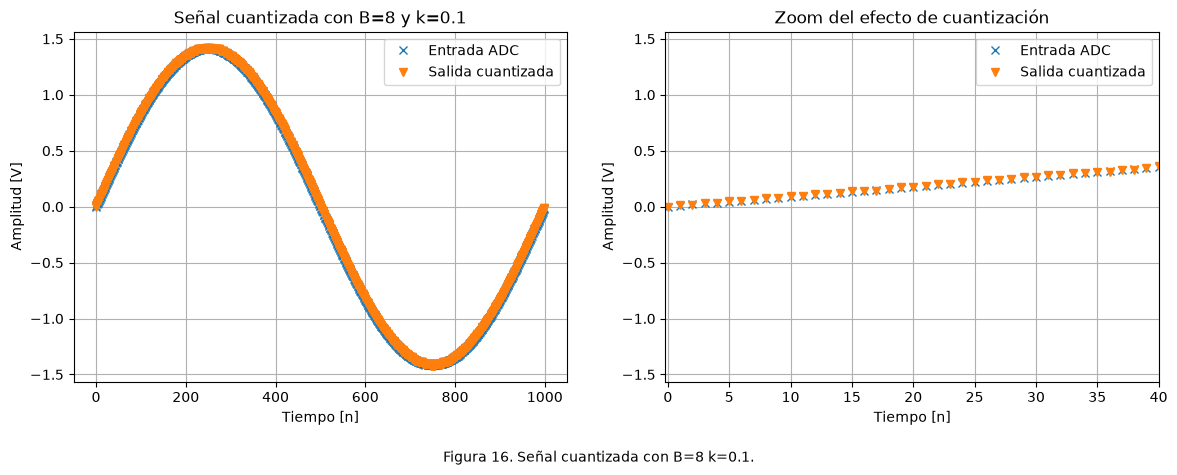

In [299]:
B = 8
k= 0.1
VF = 2

qq = 2*VF/(2**B)
ruido, Pn = gen_noise(k, qq)
noisy_xx= xx + ruido

xx_q = np.round(noisy_xx/qq)*qq
ruido_q = xx_q - noisy_xx

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax1.plot(nn, xx_q, "v", label="Salida cuantizada")

ax1.set_xlabel("Tiempo [n]")
ax1.set_ylabel("Amplitud [V]")
ax1.set_title("Señal cuantizada con B=8 y k=0.1")
ax1.legend()
ax1.grid(True)

ax2.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax2.plot(nn, xx_q, "v", label="Salida cuantizada")

ax2.set_xlim(-0.20, 40)

ax2.set_xlabel("Tiempo [n]")
ax2.set_ylabel("Amplitud [V]")
ax2.set_title("Zoom del efecto de cuantización")
ax2.legend()
ax2.grid(True)

plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 16. Señal cuantizada con B=8 k=0.1.",
            ha="center")

plt.show()

In [300]:
calcular_snr(8,0.1)

SNR cuantización = 46.915411940153994 dB
SNR analógica = 56.915411940153994 dB
SNR total = 46.50148508857174 dB


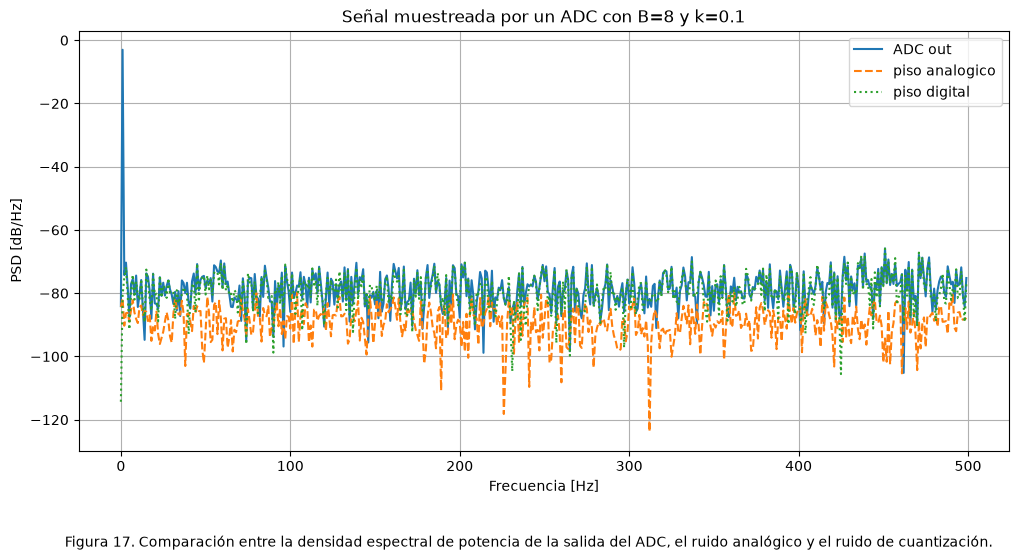

In [301]:
P_salida= espectro_potencia(xx_q)
P_ruido = espectro_potencia(ruido)
P_ruido_q = espectro_potencia(ruido_q)

#valores medios
piso_ruido = 10*np.log10(np.mean(10**(P_ruido/10)))
piso_ruido_q = 10*np.log10(np.mean(10**(P_ruido_q/10)))


plt.figure(figsize=(12,6))
plt.plot(frec, P_salida,
         label="ADC out")
plt.plot(frec, P_ruido, "--",
         label= "piso analogico")
plt.plot(frec, P_ruido_q, ":",
         label="piso digital")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.title("Señal muestreada por un ADC con B=8 y k=0.1")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 17. Comparación entre la densidad espectral de potencia de la salida del ADC, el ruido analógico y el ruido de cuantización.",
            ha="center")
plt.grid()
plt.legend()
plt.show()

Para $B=8$ y $k=0.1$, el ruido analógico resulta diez veces menor que el ruido de cuantización, por lo que su piso espectral aparece aproximadamente $10 dB$ por debajo. Además, al aumentar la resolución de 4 a 8 bits, la SNR de cuantización pasa de aproximadamente $22.83 dB$ a $46.92 dB$, lo que representa una mejora cercana a $24 dB$. Esto es consistente con una mejora aproximada de $6.02 dB$ por cada bit adicional. En esta configuración, la SNR total queda muy próxima a la SNR de cuantización, indicando que este ruido es el dominante.

##### 2.2.3 B=16 

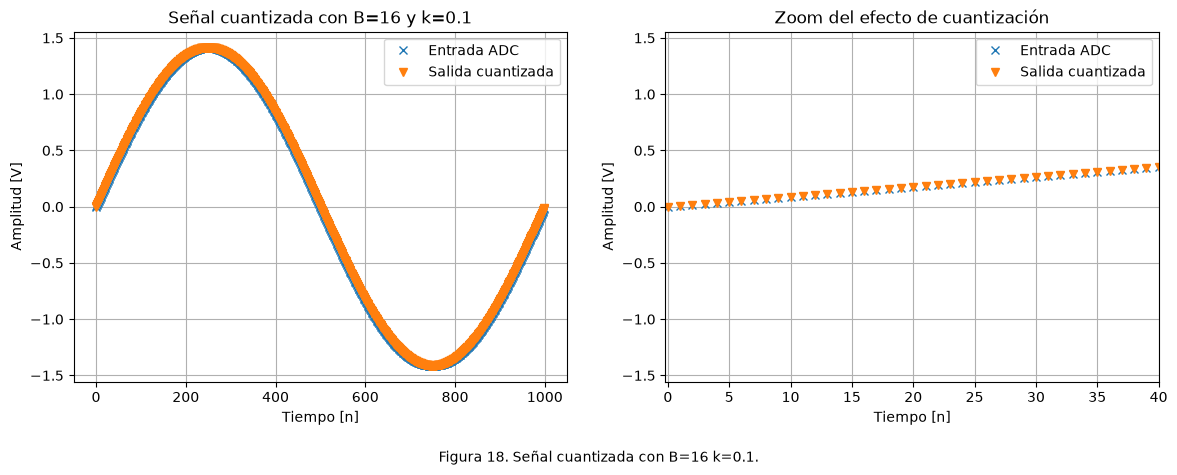

In [302]:
B = 16
k= 0.1
VF = 2

qq = 2*VF/(2**B)
ruido, Pn = gen_noise(k, qq)
noisy_xx= xx + ruido

xx_q = np.round(noisy_xx/qq)*qq
ruido_q = xx_q - noisy_xx

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax1.plot(nn, xx_q, "v", label="Salida cuantizada")

ax1.set_xlabel("Tiempo [n]")
ax1.set_ylabel("Amplitud [V]")
ax1.set_title("Señal cuantizada con B=16 y k=0.1")
ax1.legend()
ax1.grid(True)

ax2.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax2.plot(nn, xx_q, "v", label="Salida cuantizada")

ax2.set_xlim(-0.20, 40)

ax2.set_xlabel("Tiempo [n]")
ax2.set_ylabel("Amplitud [V]")
ax2.set_title("Zoom del efecto de cuantización")
ax2.legend()
ax2.grid(True)

plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 18. Señal cuantizada con B=16 k=0.1.",
            ha="center")

plt.show()

In [303]:
calcular_snr(16, 0.1)

SNR cuantización = 95.08021124639099 dB
SNR analógica = 105.08021124639099 dB
SNR total = 94.66628439480873 dB


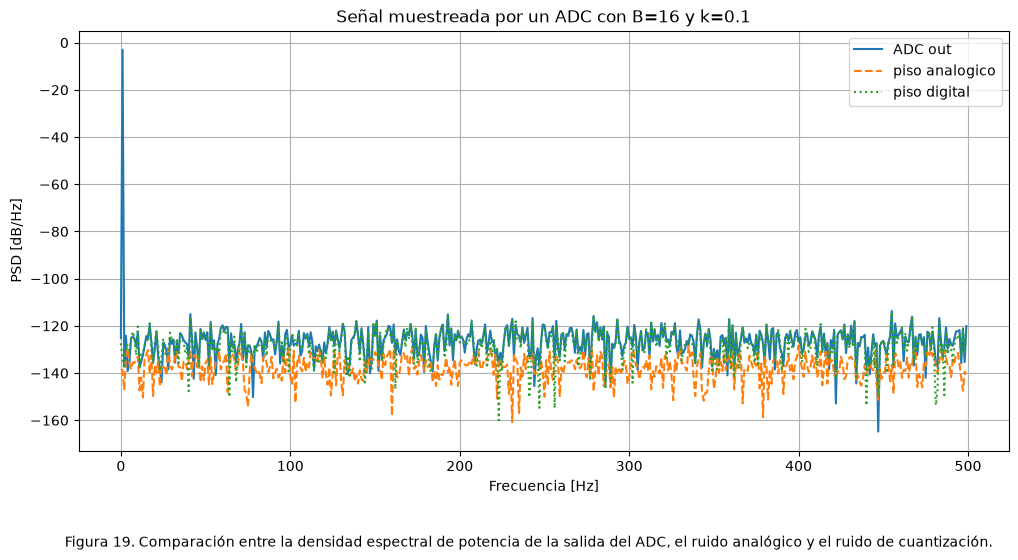

In [304]:
P_salida= espectro_potencia(xx_q)
P_ruido = espectro_potencia(ruido)
P_ruido_q = espectro_potencia(ruido_q)

#valores medios
piso_ruido = 10*np.log10(np.mean(10**(P_ruido/10)))
piso_ruido_q = 10*np.log10(np.mean(10**(P_ruido_q/10)))


plt.figure(figsize=(12,6))
plt.plot(frec, P_salida,
         label="ADC out")
plt.plot(frec, P_ruido, "--",
         label= "piso analogico")
plt.plot(frec, P_ruido_q, ":",
         label="piso digital")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.title("Señal muestreada por un ADC con B=16 y k=0.1")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 19. Comparación entre la densidad espectral de potencia de la salida del ADC, el ruido analógico y el ruido de cuantización.",
            ha="center")
plt.grid()
plt.legend()
plt.show()

Para $B=16$ y $k=0.1$, el ruido analógico continúa siendo diez veces menor que el ruido de cuantización, por lo que su piso espectral se mantiene aproximadamente $10 dB$ por debajo. Al aumentar la resolución de 8 a 16 bits, la SNR de cuantización pasa de aproximadamente $46.92 dB$ a $95.08 dB$, lo que representa una mejora cercana a $48.16 dB$ , coherente con el aumento esperado de aproximadamente $6.02 dB$ por bit. La SNR total resulta cercana a $94.67 dB$ , por lo que nuevamente el ruido de cuantización es la contribución dominante, aunque ahora su nivel es considerablemente menor debido a la mayor resolución del ADC.

##### 2.3 Con k=10

##### 2.3.1 B=4

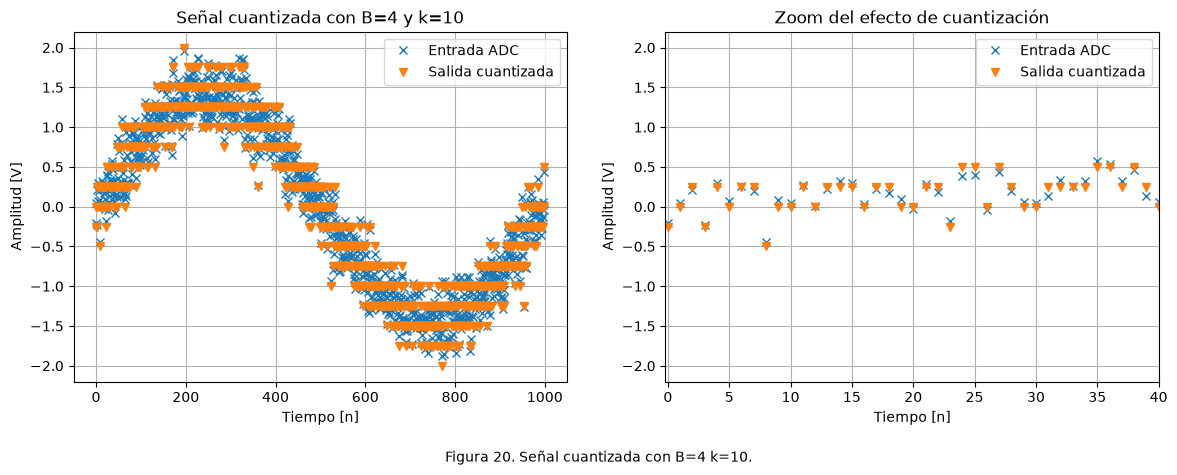

In [305]:
B = 4
k= 10
VF = 2

qq = 2*VF/(2**B)
ruido, Pn = gen_noise(k, qq)
noisy_xx= xx + ruido

xx_q = np.round(noisy_xx/qq)*qq
ruido_q = xx_q - noisy_xx

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax1.plot(nn, xx_q, "v", label="Salida cuantizada")

ax1.set_xlabel("Tiempo [n]")
ax1.set_ylabel("Amplitud [V]")
ax1.set_title("Señal cuantizada con B=4 y k=10")
ax1.legend()
ax1.grid(True)

ax2.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax2.plot(nn, xx_q, "v", label="Salida cuantizada")

ax2.set_xlim(-0.20, 40)

ax2.set_xlabel("Tiempo [n]")
ax2.set_ylabel("Amplitud [V]")
ax2.set_title("Zoom del efecto de cuantización")
ax2.legend()
ax2.grid(True)

plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 20. Señal cuantizada con B=4 k=10.",
            ha="center")

plt.show()

In [306]:
calcular_snr(4,10)

SNR cuantización = 22.833012287035498 dB
SNR analógica = 12.833012287035498 dB
SNR total = 12.419085435453246 dB


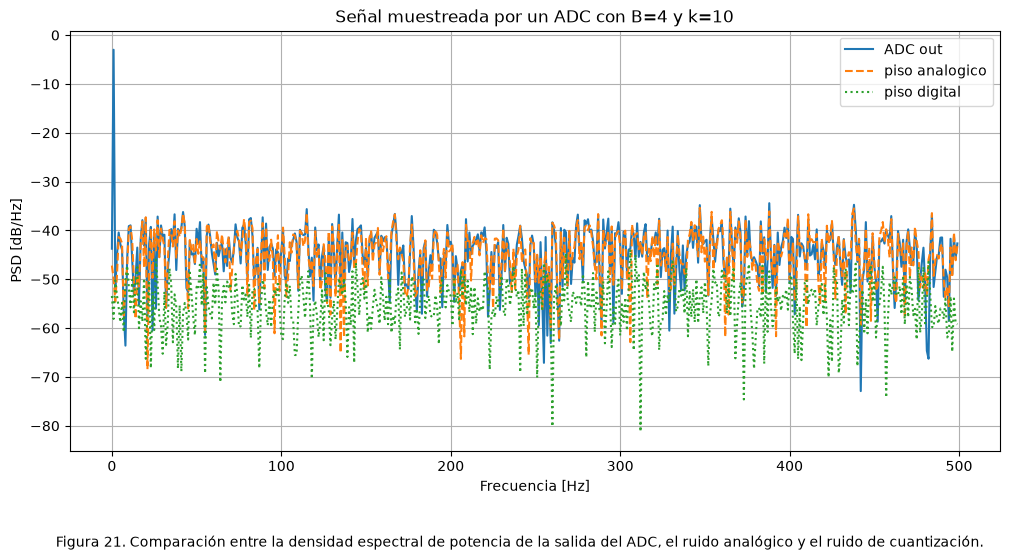

In [307]:
P_salida= espectro_potencia(xx_q)
P_ruido = espectro_potencia(ruido)
P_ruido_q = espectro_potencia(ruido_q)

#valores medios
piso_ruido = 10*np.log10(np.mean(10**(P_ruido/10)))
piso_ruido_q = 10*np.log10(np.mean(10**(P_ruido_q/10)))


plt.figure(figsize=(12,6))
plt.plot(frec, P_salida,
         label="ADC out")
plt.plot(frec, P_ruido, "--",
         label= "piso analogico")
plt.plot(frec, P_ruido_q, ":",
         label="piso digital")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.title("Señal muestreada por un ADC con B=4 y k=10")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 21. Comparación entre la densidad espectral de potencia de la salida del ADC, el ruido analógico y el ruido de cuantización.",
            ha="center")
plt.grid()
plt.legend()
plt.show()

Para $B=4$ y $k=10$, el ADC mantiene un paso de cuantización de $0.25 V$, por lo que los niveles discretos continúan siendo claramente visibles. Sin embargo, al aumentar $k_n$, la potencia del ruido analógico resulta diez veces mayor que la potencia del ruido de cuantización, provocando una mayor dispersión de la señal a la entrada del ADC. La SNR analógica disminuye aproximadamente $10 dB$ respecto de la SNR de cuantización, y la SNR total queda muy próxima a la primera. Esto indica que, para esta configuración, el comportamiento  del sistema se encuentra dominado principalmente por el ruido analógico.

##### 2.3.2 B=8

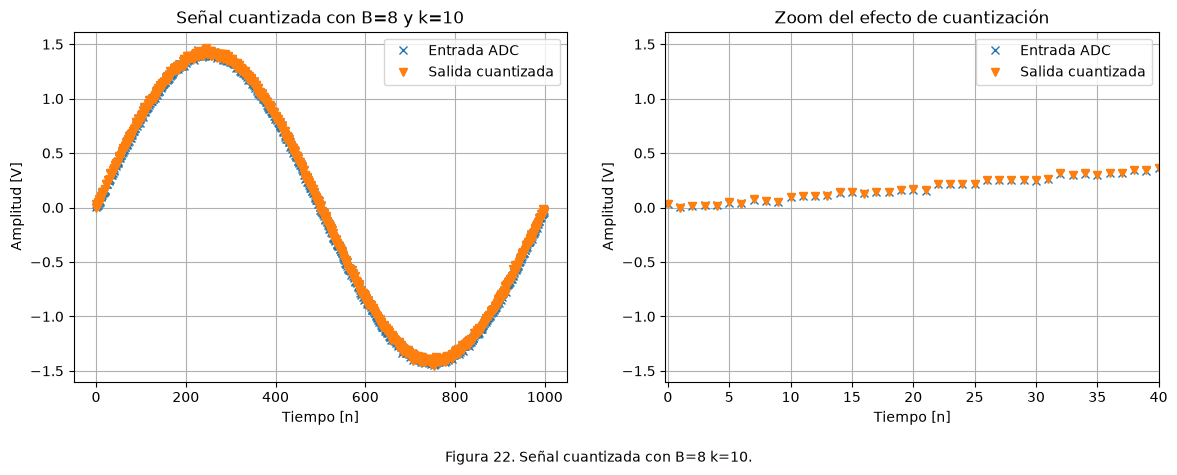

In [308]:
B = 8
k= 10
VF = 2

qq = 2*VF/(2**B)
ruido, Pn = gen_noise(k, qq)
noisy_xx= xx + ruido

xx_q = np.round(noisy_xx/qq)*qq
ruido_q = xx_q - noisy_xx

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax1.plot(nn, xx_q, "v", label="Salida cuantizada")

ax1.set_xlabel("Tiempo [n]")
ax1.set_ylabel("Amplitud [V]")
ax1.set_title("Señal cuantizada con B=8 y k=10")
ax1.legend()
ax1.grid(True)

ax2.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax2.plot(nn, xx_q, "v", label="Salida cuantizada")

ax2.set_xlim(-0.20, 40)

ax2.set_xlabel("Tiempo [n]")
ax2.set_ylabel("Amplitud [V]")
ax2.set_title("Zoom del efecto de cuantización")
ax2.legend()
ax2.grid(True)

plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 22. Señal cuantizada con B=8 k=10.",
            ha="center")

plt.show()

In [309]:
calcular_snr(8, 10)

SNR cuantización = 46.915411940153994 dB
SNR analógica = 36.915411940153994 dB
SNR total = 36.50148508857174 dB


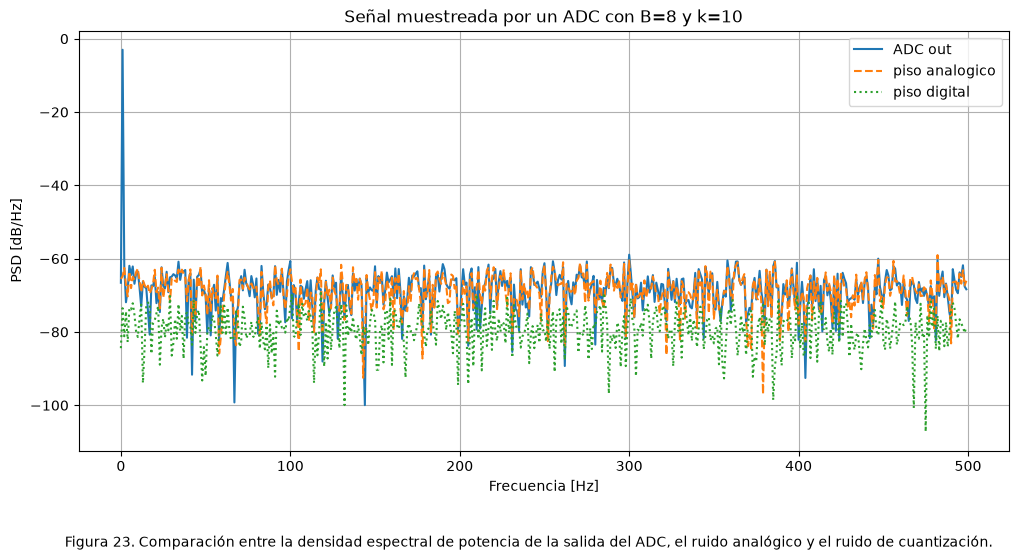

In [310]:
P_salida= espectro_potencia(xx_q)
P_ruido = espectro_potencia(ruido)
P_ruido_q = espectro_potencia(ruido_q)

#valores medios
piso_ruido = 10*np.log10(np.mean(10**(P_ruido/10)))
piso_ruido_q = 10*np.log10(np.mean(10**(P_ruido_q/10)))


plt.figure(figsize=(12,6))
plt.plot(frec, P_salida,
         label="ADC out")
plt.plot(frec, P_ruido, "--",
         label= "piso analogico")
plt.plot(frec, P_ruido_q, ":",
         label="piso digital")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.title("Señal muestreada por un ADC con B=8 y k=10")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 23. Comparación entre la densidad espectral de potencia de la salida del ADC, el ruido analógico y el ruido de cuantización.",
            ha="center")
plt.grid()
plt.legend()
plt.show()

Para $B=8$ y $k=10$, la mayor resolución del ADC reduce considerablemente el error de cuantización, por lo que la salida cuantizada sigue muy de cerca a la señal de entrada. Sin embargo, al tomar $k=10$, la potencia del ruido analógico resulta diez veces mayor que la del ruido de cuantización, lo que se refleja en la PSD mediante una separación aproximada de $10 dB$ entre ambos pisos. En consecuencia, la SNR total queda cercana a la SNR analógica, indicando que en esta configuración el comportamiento global del sistema está limitado principalmente por el ruido analógico.

##### 2.3.3 B=16

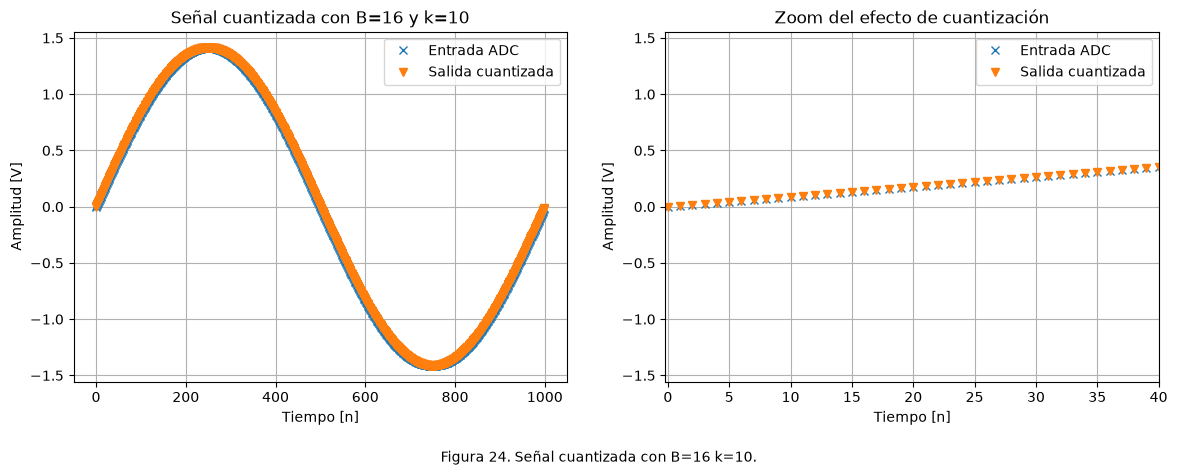

In [311]:
B = 16
k= 10
VF = 2

qq = 2*VF/(2**B)
ruido, Pn = gen_noise(k, qq)
noisy_xx= xx + ruido

xx_q = np.round(noisy_xx/qq)*qq
ruido_q = xx_q - noisy_xx

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax1.plot(nn, xx_q, "v", label="Salida cuantizada")

ax1.set_xlabel("Tiempo [n]")
ax1.set_ylabel("Amplitud [V]")
ax1.set_title("Señal cuantizada con B=16 y k=10")
ax1.legend()
ax1.grid(True)

ax2.plot(nn, noisy_xx, "x", label="Entrada ADC")
ax2.plot(nn, xx_q, "v", label="Salida cuantizada")

ax2.set_xlim(-0.20, 40)

ax2.set_xlabel("Tiempo [n]")
ax2.set_ylabel("Amplitud [V]")
ax2.set_title("Zoom del efecto de cuantización")
ax2.legend()
ax2.grid(True)

plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 24. Señal cuantizada con B=16 k=10.",
            ha="center")

plt.show()

In [312]:
calcular_snr(16,10)

SNR cuantización = 95.08021124639099 dB
SNR analógica = 85.08021124639099 dB
SNR total = 84.66628439480873 dB


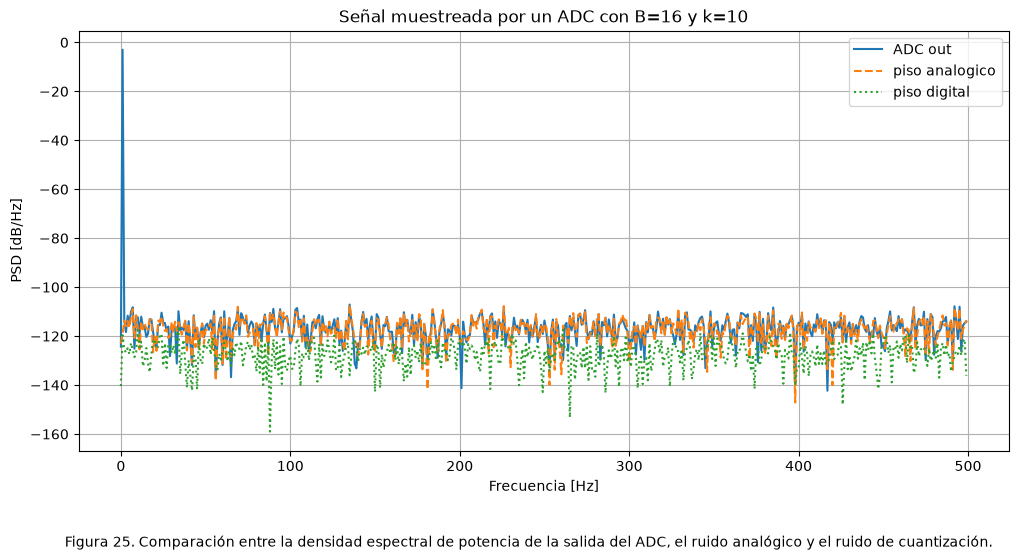

In [313]:
P_salida= espectro_potencia(xx_q)
P_ruido = espectro_potencia(ruido)
P_ruido_q = espectro_potencia(ruido_q)

#valores medios
piso_ruido = 10*np.log10(np.mean(10**(P_ruido/10)))
piso_ruido_q = 10*np.log10(np.mean(10**(P_ruido_q/10)))


plt.figure(figsize=(12,6))
plt.plot(frec, P_salida,
         label="ADC out")
plt.plot(frec, P_ruido, "--",
         label= "piso analogico")
plt.plot(frec, P_ruido_q, ":",
         label="piso digital")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.title("Señal muestreada por un ADC con B=16 y k=10")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 25. Comparación entre la densidad espectral de potencia de la salida del ADC, el ruido analógico y el ruido de cuantización.",
            ha="center")
plt.grid()
plt.legend()
plt.show()

Para $B=16$ y $k=10$, el elevado número de bits hace que el error de cuantización sea muy pequeño, por lo que la señal cuantizada prácticamente se superpone con la señal de entrada. Sin embargo, como $P_n=10P_q$, el ruido analógico posee diez veces más potencia que el ruido de cuantización, observándose en la PSD un piso analógico aproximadamente $10 dB$ por encima del piso digital. La SNR de cuantización alcanza aproximadamente $95.08 dB$, mientras que la SNR respecto del ruido analógico es de $85.08 dB$. Al considerar ambas contribuciones, la SNR total resulta aproximadamente $84.67 dB$, quedando cercana a la SNR analógica, lo que indica que el ruido analógico continúa siendo la principal limitación del sistema.

Con el objetivo de comparar de manera conjunta las distintas configuraciones analizadas, se resumen en la siguiente tabla los valores de SNR asociados al ruido de cuantización, al ruido analógico y al ruido total para cada combinación de $B$ y $k$. Esta comparación permite observar con mayor claridad el efecto que tiene la cantidad de bits sobre la resolución del ADC y el efecto de $k$ sobre la relación entre ambas fuentes de ruido. Para el cálculo de la SNR total se consideran las contribuciones de ruido como incorreladas entre sí, por lo que sus potencias pueden sumarse.

In [314]:
tabla_snr = pd.DataFrame({
    "B [bits]": [4, 4, 4, 8, 8, 8, 16, 16, 16],
    "k": [0.1, 1, 10, 0.1, 1, 10, 0.1, 1, 10],
    "SNR cuantización [dB]": [22.83, 22.83, 22.83,
                              46.92, 46.92, 46.92,
                              95.08, 95.08, 95.08],
    "SNR analógica [dB]": [32.83, 22.83, 12.83,
                            56.92, 46.92, 36.92,
                            105.08, 95.08, 85.08],
    "SNR total [dB]": [22.42, 19.82, 12.42,
                        46.50, 43.91, 36.50,
                        94.67, 92.07, 84.67]
})

display(tabla_snr)

,B [bits],k,SNR cuantización [dB],SNR analógica [dB],SNR total [dB]
0,4,0.1,22.83,32.83,22.42
1,4,1.0,22.83,22.83,19.82
2,4,10.0,22.83,12.83,12.42
3,8,0.1,46.92,56.92,46.50
4,8,1.0,46.92,46.92,43.91
5,8,10.0,46.92,36.92,36.50
6,16,0.1,95.08,105.08,94.67
7,16,1.0,95.08,95.08,92.07
8,16,10.0,95.08,85.08,84.67


A partir de los resultados se observa que, para un mismo valor de $k$, el aumento de la cantidad de bits produce una mejora importante de la SNR. Esto se debe a que al aumentar $B$ disminuye el paso de cuantización y, en consecuencia, también disminuye la potencia del ruido de cuantización. Los resultados obtenidos muestran una mejora aproximada de $6.02 dB$ por cada bit adicional, en concordancia con lo observado en los distintos casos.

Por otro lado, para una cantidad fija de bits, el parámetro $k$ determina cuál de las dos fuentes de ruido tiene mayor peso en el sistema. Para $k=0.1$, la potencia del ruido analógico es diez veces menor que la del ruido de cuantización, por lo que la SNR total queda cercana a la SNR de cuantización. Para $k=1$, ambas contribuciones tienen igual potencia y la SNR total disminuye aproximadamente $3 dB$ respecto de cada una por separado. Finalmente, para $k=10$, el ruido analógico pasa a ser dominante y la SNR total queda próxima a la SNR analógica.

En conclusión, aumentar la cantidad de bits permite representar la señal con mayor precisión y reducir el error de cuantización, pero la calidad final del sistema no depende únicamente de la resolución del ADC. También depende de la potencia del ruido analógico presente a la entrada. Por lo tanto, la SNR total resulta una medida útil para evaluar el comportamiento global del sistema, ya que permite determinar cuál de las fuentes de ruido termina limitando la calidad de la señal digitalizada.

#### Conclusión 

En este trabajo se analizó el funcionamiento de un ADC considerando tanto el ruido analógico como el error de cuantización. En el primer punto se verificó que el error de cuantización presenta un comportamiento aproximadamente uniforme e incorrelado para las condiciones estudiadas. Luego, al variar la cantidad de bits y el parámetro k, se observó que aumentar B disminuye el paso de cuantización y mejora la SNR, mientras que k determina cuál de las dos fuentes de ruido tiene mayor influencia. En consecuencia, una mayor resolución mejora la representación digital de la señal, pero la calidad final del sistema queda condicionada por la fuente de ruido dominante.